<a href="https://colab.research.google.com/github/emanaak04-svg/sleep-apnea-detection/blob/main/amna/eeg_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 01: Install Libraries and Mount Google Drive
We install the required libraries and connect Google Drive
so we can access the MIT-BIH dataset files.

In [2]:
!pip install wfdb -q

from google.colab import drive
drive.mount('/drive')

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("All libraries imported")

Drive already mounted at /drive; to attempt to forcibly remount, call drive.mount("/drive", force_remount=True).
All libraries imported


## 02: Load All 5 Patients and Check Channels
We load each patient file from Google Drive and print
the available channels to confirm EEG channel location.

In [3]:
DATA_PATH = "/drive/MyDrive/shhs-data"

patients = ['slp01a', 'slp02a', 'slp03', 'slp04', 'slp14']

for p in patients:
    record = wfdb.rdrecord(f"{DATA_PATH}/{p}")
    print(f"Patient: {p}")
    print(f"  Channels : {record.sig_name}")
    print(f"  Samples  : {record.p_signal.shape}")
    print(f"  Duration : {record.p_signal.shape[0]/record.fs/3600:.2f} hours")
    print()

Patient: slp01a
  Channels : ['ECG', 'BP', 'EEG (C4-A1)', 'Resp (sum)']
  Samples  : (1800000, 4)
  Duration : 2.00 hours

Patient: slp02a
  Channels : ['ECG', 'BP', 'EEG (O2-A1)', 'Resp (nasal)']
  Samples  : (2700000, 4)
  Duration : 3.00 hours

Patient: slp03
  Channels : ['ECG', 'BP', 'EEG (C3-O1)', 'Resp (nasal)']
  Samples  : (5400000, 4)
  Duration : 6.00 hours

Patient: slp04
  Channels : ['ECG', 'BP', 'EEG (C3-O1)', 'Resp (nasal)']
  Samples  : (5400000, 4)
  Duration : 6.00 hours

Patient: slp14
  Channels : ['ECG', 'BP', 'EEG (C3-O1)', 'Resp (nasal)']
  Samples  : (5400000, 4)
  Duration : 6.00 hours



## 03: Extract EEG Signal and Labels for All Patients
For each patient we extract the EEG signal from channel 2.
We load the apnea annotations from the .st file and create
one label per 30-second window. 1 = apnea, 0 = normal.
We store all windows and labels in lists.

In [4]:
all_eeg_segments = []
all_labels = []

WINDOW_SIZE = 30  # seconds

for p in patients:
    # Copy files to local Colab first (wfdb needs local files)
    import shutil
    shutil.copy(f"{DATA_PATH}/{p}.dat", f"/content/{p}.dat")
    shutil.copy(f"{DATA_PATH}/{p}.hea", f"/content/{p}.hea")
    shutil.copy(f"{DATA_PATH}/{p}.st", f"/content/{p}.st")

    record = wfdb.rdrecord(f"/content/{p}")
    fs = record.fs
    eeg = record.p_signal[:, 2]  # EEG is channel 2

    ann = wfdb.rdann(f"/content/{p}", 'st')
    samples_per_window = int(WINDOW_SIZE * fs)

    for i, sample in enumerate(ann.sample):
        label_text = ann.aux_note[i].strip()
        label = 1 if 'A' in label_text else 0

        start = sample
        end = start + samples_per_window

        if end <= len(eeg):
            segment = eeg[start:end]
            all_eeg_segments.append(segment)
            all_labels.append(label)

all_labels = np.array(all_labels)
total = len(all_labels)
apnea = np.sum(all_labels == 1)
normal = np.sum(all_labels == 0)

print(f"Segmentation complete!")
print(f"Total windows : {total}")
print(f"Normal        : {normal} ({100*normal/total:.1f}%)")
print(f"Apnea         : {apnea} ({100*apnea/total:.1f}%)")

Segmentation complete!
Total windows : 2754
Normal        : 2389 (86.7%)
Apnea         : 365 (13.3%)


## 04: Visualize EEG Class Distribution
We plot a bar chart showing how many normal vs apnea
windows we have across all 5 patients for the EEG signal.

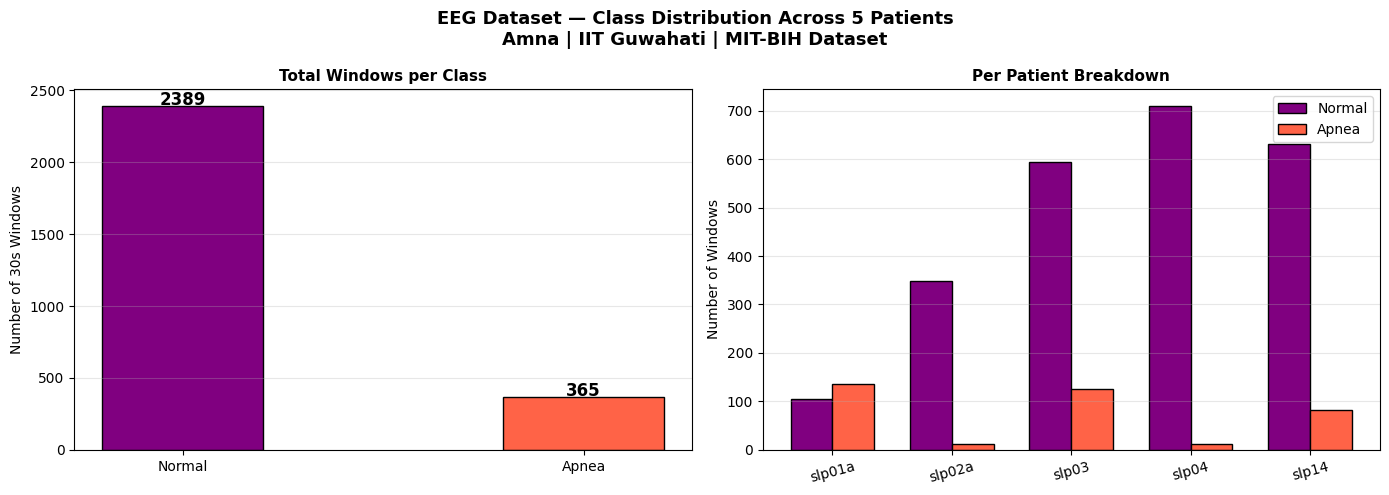

Plot saved!


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("EEG Dataset — Class Distribution Across 5 Patients\nAmna | IIT Guwahati | MIT-BIH Dataset",
             fontsize=13, fontweight='bold')

# --- Plot 1: Bar chart ---
ax1 = axes[0]
labels_names = ['Normal', 'Apnea']
counts = [normal, apnea]
colors = ['purple', 'tomato']
bars = ax1.bar(labels_names, counts, color=colors, edgecolor='black', width=0.4)
ax1.set_title("Total Windows per Class", fontsize=11, fontweight='bold')
ax1.set_ylabel("Number of 30s Windows")
for bar, count in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(count), ha='center', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# --- Plot 2: Per patient breakdown ---
ax2 = axes[1]
patient_apnea = []
patient_normal = []

for p in patients:
    record = wfdb.rdrecord(f"/content/{p}")
    fs = record.fs
    eeg = record.p_signal[:, 2]
    ann = wfdb.rdann(f"/content/{p}", 'st')
    samples_per_window = int(WINDOW_SIZE * fs)

    p_apnea = 0
    p_normal = 0
    for i, sample in enumerate(ann.sample):
        label_text = ann.aux_note[i].strip()
        label = 1 if 'A' in label_text else 0
        start = sample
        end = start + samples_per_window
        if end <= len(eeg):
            if label == 1:
                p_apnea += 1
            else:
                p_normal += 1
    patient_apnea.append(p_apnea)
    patient_normal.append(p_normal)

x = np.arange(len(patients))
width = 0.35
ax2.bar(x - width/2, patient_normal, width, label='Normal', color='purple', edgecolor='black')
ax2.bar(x + width/2, patient_apnea, width, label='Apnea', color='tomato', edgecolor='black')
ax2.set_title("Per Patient Breakdown", fontsize=11, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(patients, rotation=15)
ax2.set_ylabel("Number of Windows")
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("/drive/MyDrive/shhs-data/eeg_segmentation_plot.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

## 05: Save the Segmented EEG Dataset
We save all EEG windows and their labels to numpy files.
Day 3 will load directly from these saved files to extract
EEG band power features without reprocessing raw signals.

In [6]:
X_eeg = np.array(all_eeg_segments)
y = np.array(all_labels)

np.save("/drive/MyDrive/shhs-data/X_eeg.npy", X_eeg)
np.save("/drive/MyDrive/shhs-data/y_labels.npy", y)

print(f"Dataset saved to Google Drive!")
print(f"X_eeg shape  : {X_eeg.shape}")
print(f"y shape      : {y.shape}")
print(f"\nX_eeg.npy   → each row is one 30s EEG window")
print(f"y_labels.npy → 0 = normal, 1 = apnea")

Dataset saved to Google Drive!
X_eeg shape  : (2754, 7500)
y shape      : (2754,)

X_eeg.npy   → each row is one 30s EEG window
y_labels.npy → 0 = normal, 1 = apnea
